# Week 9 - Exercise
### Notebook created by Jonathan Penava

For this exercise you are going to try to try and predict the carat range of a diamond based on some of its properties.  Start by importing the standard libraries and reading in the 'diamonds.csv' file. 

Drop the 'Color', 'Clarity', and 'Unnamed: 0' Columns.

You will need to change the 'cut' values into int values.

Referencing what we did in week 5, create a new column for carat ranges with the values '0-1', '1-2','2-3','3-4','4-5','5-6'

Drop the column 'carat' after you have created the carat ranges column

Using K-Nearest Neighbours classify your carat ranges based on the other values in your dataframe.  Print out an accuracy score and a classification report for your algorithm.

Create a diagram of error rates for different values of K.  What value of K will give you a more accurate result?

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('diamonds.csv')

In [29]:
df.head()

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [30]:
df['cut'].unique()

array(['Ideal', 'Premium', 'Good', 'Very Good', 'Fair'], dtype=object)

In [31]:
df.drop('color', axis=1, inplace=True)
df.drop('clarity', axis=1, inplace=True)
df.drop('Unnamed: 0', axis=1, inplace=True)



In [32]:

cut_mapping = {
    'Ideal': 0,
    'Premium': 1,
    'Good': 2,
    'Very Good': 3,
    'Fair': 3
}
df['cut'].replace(cut_mapping, inplace=True)


C:\Users\hp\AppData\Local\Temp\ipykernel_22120\1879485231.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['cut'].replace(cut_mapping, inplace=True)
C:\Users\hp\AppData\Local\Temp\ipykernel_22120\1879485231.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['cut'].replace(cut_mapping, inpl

In [33]:
bins = [0, 1, 2, 3, 4, 5, 6]
labels = ["0-1", "1-2", "2-3", "3-4", "4-5", "5-6"]
df['caratrange'] = pd.cut(df['carat'], bins=bins, labels=labels, right=False)
df.drop('carat', axis=1, inplace=True)


In [34]:
df.dropna(axis=0, inplace=True)  
X = df.drop('caratrange', axis=1)
y = df['caratrange']

In [35]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=87)

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)
pred = knn.predict(X_test)
print('Accuracy:', accuracy_score(y_test, pred))
print(classification_report(y_test, pred))


Accuracy: 0.9157706093189965
              precision    recall  f1-score   support

         0-1       0.96      0.96      0.96     10432
         1-2       0.86      0.88      0.87      5068
         2-3       0.65      0.56      0.60       669
         3-4       1.00      0.11      0.20         9
         4-5       0.00      0.00      0.00         4

    accuracy                           0.92     16182
   macro avg       0.69      0.50      0.53     16182
weighted avg       0.91      0.92      0.91     16182



c:\Users\hp\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\hp\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\hp\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [37]:
error_rate = []
for k in range(1, 42):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    pred_k = knn.predict(X_test)
    error_rate.append(np.mean(pred_k != y_test))



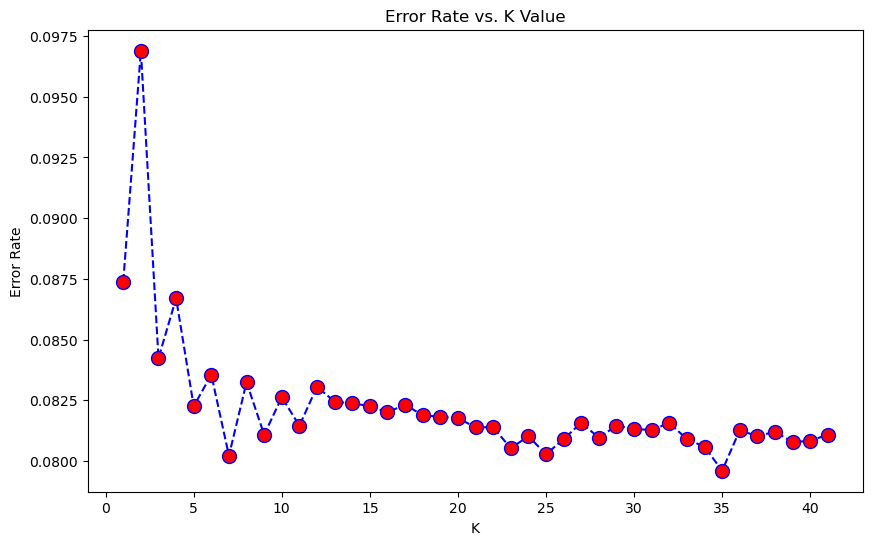

In [38]:
plt.figure(figsize=(10,6))
plt.plot(range(1,42), error_rate, color='blue', linestyle='dashed', marker='o', markerfacecolor='red', markersize=10)
plt.title('Error Rate vs. K Value')
plt.xlabel('K')
plt.ylabel('Error Rate')
plt.show()
